# 01 — Data Collection & Multi-Asset Pipeline Ingestion

**7030DATSCI · Event-Driven Market Impact & Causal Prediction Pipeline** **Author:** Ibrahim Haroun · **LJMU 2025–2026** · **Version:** 3.0 (Full Reproducible Pipeline)

---

## Purpose of this Notebook

This notebook executes the ingestion, temporal alignment, and quality validation for all raw data sources required to evaluate whether political communications, monetary policy announcements, and global geopolitical shocks affect the S&P 500 (SPY), and whether these event-derived signals improve short-term predictive modeling over a market-only baseline.

### Core Methodological Objectives:
1. **Multi-Source Ingestion:** Ingest daily market prices (SPY/VIX), FRED macroeconomic indicators, presidential communications from The American Presidency Project (APP), FOMC meeting schedules, and continuous geopolitical risk event streams from the GDELT 2.0 Global Knowledge Graph.
2. **Temporal Alignment & Leakage Prevention:** Map post-market releases (>16:00 EST) and non-trading day events to trading day $t+1$ to strictly eliminate look-ahead bias prior to feature engineering.
3. **High-Throughput Aggregation:** Stream-aggregate raw event files into daily continuous metrics (Goldstein Scale, Average Tone, Event Volume) using a zero-RAM memory-efficient pipeline.
4. **Data Lineage Verification:** Generate an auditable daily master modeling calendar (`daily_modelling_calendar_v1.parquet`) and a data quality report (`data_quality_report.parquet`) for downstream exploratory analysis and event studies.

## Scope Decisions & Pipeline Architecture

### Included in the Primary Research Pipeline

| Dataset / Methodology | Included? | Implementation Role & Methodological Justification |
| :--- | :---: | :--- |
| **SPY Daily OHLCV** | **Yes** | Primary S&P 500 benchmark proxy for log return calculations and target variable generation ($t+1$). |
| **CBOE Volatility Index (VIX)** | **Yes** | Market uncertainty control and volatility regime feature across baseline and ML models. |
| **FRED Macro Indicators** | **Yes** | Macroeconomic controls (Fed Funds Rate, CPI, 10Y–2Y Yield Spread) aligned to business-day frequency. |
| **FOMC Meeting Dates** | **Yes** | High-impact monetary policy event calendar for abnormal return and causal estimation. |
| **Presidential Communications (APP)** | **Yes** | Primary political text corpus processed via FinBERT for event detection and sentiment scoring. |
| **GDELT Geopolitical Events** | **Yes** | Stream-aggregated daily GDELT metrics (Goldstein Scale, Average Tone) controlling for geopolitical risk. |
| **Structural Causal Model (DoWhy)** | **Yes** | Causal inference graph (DAG) evaluating average causal effects under Backdoor Criterion adjustments. |

---

### Excluded / Deferred to Robustness Appendix

| Dataset / Method | Decision | Methodological Reason |
| :--- | :--- | :--- |
| **QQQ / GLD / TLT Asset Classes** | Appendix | Cross-asset checks kept as optional extensions to preserve primary focus on S&P 500 index dynamics. |
| **Intraday Tick-Level Microstructure** | Excluded | Excluded to maintain daily temporal alignment ($t+1$) and eliminate look-ahead bias across text releases. |
| **Deep Learning (LSTM / Transformers)** | Excluded | Replaced by regularized linear (LASSO) and tree-based ensembles (XGBoost/LightGBM) to preserve SHAP interpretability. |

## 0. Setup, Environment Configuration, and Module Imports

This section initializes the project environment, verifies required Python dependencies, configures SSL network certificates (ensuring compatibility across university and corporate networks), and imports custom modular collectors from `src/data_collector.py`.

### Pipeline Initialization Protocols:
* **Automated Package Check:** Verifies and dynamically installs core data engineering dependencies (`pandas`, `yfinance`, `fredapi`, `pyarrow`, `duckdb`, etc.).
* **SSL Certificate Binding:** Binds `certifi` CA bundles to handle secure HTTPS requests for Yahoo Finance, FRED, APP UCSB, and GDELT endpoints.
* **Module Resolution:** Appends the project root directory to `sys.path` to enable clean, modular imports from `src/`.

In [28]:
# ── 0. Setup and Dependencies ───────────────────────────────────────────────────

import importlib
import subprocess
from pathlib import Path
import sys
import os
import ssl
import json
import warnings
import logging

# ── 1. Required Packages Verification ─────────────────────────────────────────
REQUIRED_PACKAGES = [
    "pandas", 
    "numpy", 
    "yfinance", 
    "fredapi", 
    "pyarrow", 
    "fastparquet",
    "matplotlib", 
    "certifi", 
    "requests",
    "duckdb",
    "bs4"
]

def ensure_package(package: str) -> None:
    """Installs missing packages dynamically if not present in environment."""
    try:
        importlib.import_module(package)
    except ImportError:
        print(f"Installing missing package: {package}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

for pkg in REQUIRED_PACKAGES:
    ensure_package(pkg)

print("✓ All required packages verified.")


# ── 2. Standard Imports & Network SSL Configuration ───────────────────────────
import certifi
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from fredapi import Fred

warnings.filterwarnings("ignore")

# SSL Certificate binding for macOS and restricted institutional networks
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
os.environ["CURL_CA_BUNDLE"] = certifi.where()
ssl._create_default_https_context = ssl.create_default_context

# Plotting aesthetics configuration
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

print("✓ Core libraries loaded and SSL context configured.")


# ── 3. Project Directory Resolution & Modular Ingestion Imports ──────────────
# Resolve project root and append to python path for src/ imports
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data_collector import (
    load_config,
    MarketDataCollector,
    APPCollector,
    NewsCollector,
    GDELTCollector
)

# Configure logging for pipeline visibility
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    datefmt="%H:%M:%S"
)

# Load master YAML configuration file
config_file = project_root / "config.yaml"
if config_file.exists():
    config = load_config(str(config_file))
    print(f"✓ Configuration loaded successfully from: {config_file.name}")
else:
    # Fallback if executing directly from project root directory
    config = load_config("config.yaml")
    print("✓ Configuration loaded successfully from root directory.")

✓ All required packages verified.
✓ Core libraries loaded and SSL context configured.
✓ Configuration loaded successfully from: config.yaml


---
## 1. Project Configuration, Directory Hierarchy, and Data Persistence Helpers

This section establishes the global configuration parameters, directory paths, primary market tickers, date boundaries (2015–2025), and defensive file persistence functions for the multi-source data collection pipeline.

### Architectural Parameters & Configuration Standards:
* **Primary Target Asset:** `SPY` (SPDR S&P 500 ETF Trust) serving as the liquid proxy for the U.S. large-cap equity market.
* **Timeline Horizon:** `2015-01-01` through `2025-12-31` (covering four Presidential administration transitions, FOMC rate hike/cut cycles, and global geopolitical shocks).
* **Directory Structure:** Initializes local storage directories (`data/raw`, `data/interim`, `reports/figures`, `data/raw/app_csv`) and a project-isolated `yfinance` SQLite cache directory to prevent OS-level permission locks.
* **Defensive Cache Loader (`load_if_cached`):** Checks existing `.parquet` and `.csv` files for non-zero row counts, ensuring corrupted or empty (0-row) API cache artifacts are automatically bypassed and re-fetched.

In [29]:
# ── 1. Project Configuration & Persistence Infrastructure ──────────────────────

from pathlib import Path
import pandas as pd
import yfinance as yf

# ── Project Directory Setup ─────────────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RAW = DATA_DIR / "raw"
INTERIM = DATA_DIR / "interim"
FIGURES = PROJECT_ROOT / "reports" / "figures"

for folder in [RAW, INTERIM, FIGURES, RAW / "app_csv"]:
    folder.mkdir(parents=True, exist_ok=True)

# ── Isolated yfinance Cache Configuration ──────────────────────────────────
# Prevents OperationalError('unable to open database file') on restricted/macOS environments
YF_CACHE_DIR = PROJECT_ROOT / ".cache" / "yfinance"
YF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
try:
    yf.set_tz_cache_location(str(YF_CACHE_DIR))
except Exception as cache_error:
    print(f"yfinance cache set fallback: {cache_error}")

# ── Primary Horizon & Asset Configuration ───────────────────────────────────
START_DATE = "2015-01-01"
END_DATE = "2025-12-31"

TARGET_TICKER = "SPY"
OPTIONAL_TICKERS = ["QQQ", "GLD", "TLT"]  # Preserved for optional appendix robustness checks

print("=" * 75)
print(f"PROJECT ROOT : {PROJECT_ROOT}")
print(f"RAW DATA PATH: {RAW}")
print(f"SAMPLE PERIOD: {START_DATE} → {END_DATE}")
print(f"MAIN TICKER  : {TARGET_TICKER}")
print("=" * 75)


# ── File Persistence & Cache Validation Helpers ─────────────────────────────
def save_table(df: pd.DataFrame, path: Path, index: bool = True) -> Path:
    """Save DataFrame to parquet safely, with CSV fallback on engine failure."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        df.to_parquet(path, index=index)
        return path
    except Exception as parquet_error:
        csv_path = path.with_suffix(".csv")
        df.to_csv(csv_path, index=index)
        print(f"Parquet save failed for {path.name}; saved CSV instead. Reason: {parquet_error}")
        return csv_path


def flatten_yfinance_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Flatten yfinance MultiIndex columns if present."""
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]
    return df


def normalise_date_index(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure a sorted datetime index named 'date'."""
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df.index.name = "date"
    return df.sort_index()


def load_if_cached(path: Path, force: bool = False):
    """
    Load cached table if file exists AND contains non-zero rows.
    Empty cache files (0 rows) are ignored to force a fresh API download.
    """
    path = Path(path)
    if force:
        return None
        
    if path.exists():
        try:
            cached = pd.read_parquet(path)
            if not cached.empty:
                return cached
            print(f"Cache file {path.name} exists but is empty (0 rows) — re-fetching data.")
        except Exception:
            pass
            
    csv_fallback = path.with_suffix(".csv")
    if csv_fallback.exists():
        try:
            cached = pd.read_csv(csv_fallback, index_col=0, parse_dates=True)
            if not cached.empty:
                return cached
            print(f"Cache CSV {csv_fallback.name} exists but is empty (0 rows) — re-fetching data.")
        except Exception:
            pass
            
    return None

PROJECT ROOT : /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI
RAW DATA PATH: /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/data/raw
SAMPLE PERIOD: 2015-01-01 → 2025-12-31
MAIN TICKER  : SPY


---
## 2. Primary Market Asset — SPY Daily Price Series & Return Feature Engineering

This section downloads and validates daily Open-High-Low-Close-Volume (OHLCV) price series for `SPY` (SPDR S&P 500 ETF Trust). SPY serves as the primary benchmark asset for evaluating event-driven abnormal returns ($\text{AR}$) and defining next-day direction prediction targets ($t+1$).

### Methodological & Feature Construction Protocol:
* **Data Artifacts Produced:**
  1. `spy_ohlcv.parquet`: Raw daily price, adjusted close, and volume series.
  2. `spy_returns.parquet`: Log returns, directional indicators, momentum indicators, and forward-shifted prediction targets.
* **Target Feature Definition ($t+1$):**
  $$\text{Log Return}_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$
  $$\text{Target Next-Day Return}_{t+1} = \text{Log Return}_{t+1} = \text{shift}(-1)$$
* **Data Leakage Control:** All predictor features (1-day lagged returns, 5-day rolling momentum, 21-day annualized volatility) are computed strictly using past market prices ($\le t$) to ensure non-overlapping, zero-leakage alignment with the $t+1$ target.

In [30]:
# ── 2. Market Data Ingestion & Return Target Construction ─────────────────────

from pathlib import Path
import numpy as np
import pandas as pd
import yfinance as yf

SPY_PATH = RAW / "spy_ohlcv.parquet"
RETURNS_PATH = RAW / "spy_returns.parquet"
FORCE_REFRESH_SPY = False  # Set True to force re-download from Yahoo Finance

# ── 1. Fetch or Load Cached SPY OHLCV ─────────────────────────────────────────
spy_ohlcv = load_if_cached(SPY_PATH, force=FORCE_REFRESH_SPY)

if spy_ohlcv is not None:
    print(f"✓ Loaded cached SPY OHLCV from {SPY_PATH.relative_to(PROJECT_ROOT)} "
          f"({len(spy_ohlcv):,} rows). Set FORCE_REFRESH_SPY = True to re-download.")
else:
    print(f"Fetching SPY OHLCV from Yahoo Finance ({START_DATE} → {END_DATE})...")
    spy_ohlcv = yf.download(
        TARGET_TICKER,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        progress=False,
    )

    spy_ohlcv = flatten_yfinance_columns(spy_ohlcv)
    spy_ohlcv = normalise_date_index(spy_ohlcv)
    spy_ohlcv.columns = [c.lower().replace(" ", "_") for c in spy_ohlcv.columns]

    # Standardize column schema
    expected_cols = ["open", "high", "low", "close", "adj_close", "volume"]
    available_cols = [c for c in expected_cols if c in spy_ohlcv.columns]
    spy_ohlcv = spy_ohlcv[available_cols]

    save_table(spy_ohlcv, SPY_PATH)

    print(f"✓ SPY OHLCV Ingested: {len(spy_ohlcv):,} rows")
    print(f"  Date Range : {spy_ohlcv.index.min().date()} → {spy_ohlcv.index.max().date()}")
    print(f"  Columns    : {list(spy_ohlcv.columns)}")

spy_ohlcv.head()


# ── 2. Construct Return Features & Next-Day Prediction Targets ────────────────
price_col = "adj_close" if "adj_close" in spy_ohlcv.columns else "close"

spy_returns = pd.DataFrame(index=spy_ohlcv.index)
spy_returns["spy_close"] = spy_ohlcv[price_col]

# Continuous log returns and simple percentage returns
spy_returns["spy_log_return"] = np.log(spy_returns["spy_close"] / spy_returns["spy_close"].shift(1))
spy_returns["spy_simple_return"] = spy_returns["spy_close"].pct_change()
spy_returns["spy_return_direction"] = (spy_returns["spy_log_return"] > 0).astype(int)

# ── Prediction Target Variables (Forward-shifted t+1) ─────────────────────────
# Target: next trading day's log return and binary direction
spy_returns["target_next_day_log_return"] = spy_returns["spy_log_return"].shift(-1)
spy_returns["target_next_day_direction"] = (spy_returns["target_next_day_log_return"] > 0).astype(int)

# ── Baseline Historical Predictors (strictly <= t) ───────────────────────────
spy_returns["lag1_return"] = spy_returns["spy_log_return"].shift(1)
spy_returns["rolling_5d_return"] = spy_returns["spy_log_return"].rolling(5).sum()
spy_returns["rolling_21d_return"] = spy_returns["spy_log_return"].rolling(21).sum()

# Annualized 21-day rolling historical volatility (sqrt(252))
spy_returns["rolling_21d_volatility"] = spy_returns["spy_log_return"].rolling(21).std() * np.sqrt(252)

# Drop initial NaN rows created by rolling windows/lags and final row (missing t+1 target)
spy_returns = spy_returns.dropna()
save_table(spy_returns, RETURNS_PATH)

print("=" * 75)
print(f"✓ SPY Return Features Processed & Saved → {RETURNS_PATH.name}")
print(f"  Valid Modeling Days : {len(spy_returns):,}")
print(f"  Features Generated   : {list(spy_returns.columns)}")
print("=" * 75)
spy_returns.head()

✓ Loaded cached SPY OHLCV from data/raw/spy_ohlcv.parquet (2,765 rows). Set FORCE_REFRESH_SPY = True to re-download.
✓ SPY Return Features Processed & Saved → spy_returns.parquet
  Valid Modeling Days : 2,743
  Features Generated   : ['spy_close', 'spy_log_return', 'spy_simple_return', 'spy_return_direction', 'target_next_day_log_return', 'target_next_day_direction', 'lag1_return', 'rolling_5d_return', 'rolling_21d_return', 'rolling_21d_volatility']


,spy_close,spy_log_return,spy_simple_return,spy_return_direction,target_next_day_log_return,target_next_day_direction,lag1_return,rolling_5d_return,rolling_21d_return,rolling_21d_volatility
date,,,,,,,,,,
2015-02-03,169.200531,0.014358,0.014462,1,-0.003815,0,0.012307,0.010305,-0.002876,0.178844
2015-02-04,168.556213,-0.003815,-0.003808,0,0.010045,1,0.014358,0.019397,0.011533,0.167059
2015-02-05,170.257812,0.010045,0.010095,1,-0.002769,0,-0.003815,0.020240,0.031041,0.165991
2015-02-06,169.786972,-0.002769,-0.002765,0,-0.004486,0,0.010045,0.030125,0.015888,0.161691
2015-02-09,169.027069,-0.004486,-0.004476,0,0.010597,1,-0.002769,0.013333,-0.006187,0.150426


### 2.1 Asset Base Normalization & Time-Series Trajectory

To evaluate historical growth trajectories, structural market regimes, and macroeconomic crisis points across the 2015–2025 timeline, the raw SPY adjusted close series is normalized to a baseline of $100.0$ on the first trading day ($t_0$). 

#### Rebased Index Formula:
$$\text{Rebased Price}_t = \left( \frac{\text{Price}_t}{\text{Price}_{t_0}} \right) \times 100$$

This transformation allows for direct visual and statistical benchmarking against market volatility spikes (e.g., March 2020 COVID shock, 2022 Fed rate hiking cycle) without altering underlying log return calculations.

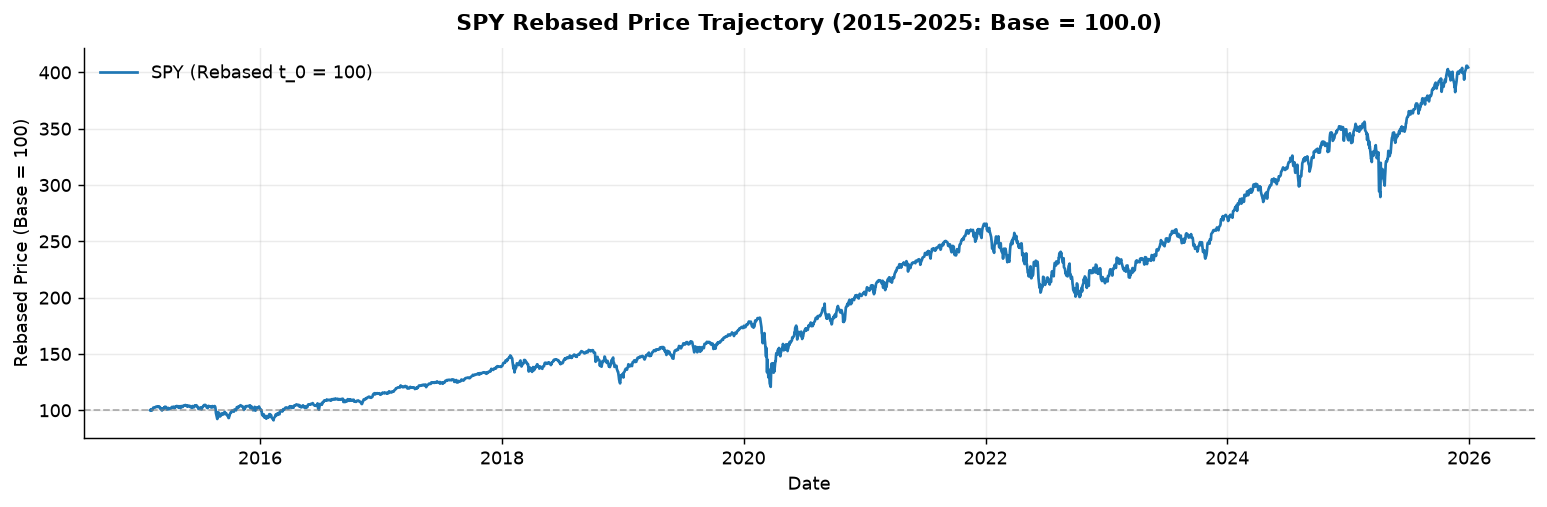

✓ Figure saved successfully → reports/figures/01_spy_rebased_price.png


In [31]:
# ── Section 2.1: Rebased Price Visualization & Figure Generation ───────────────

import matplotlib.pyplot as plt
from pathlib import Path

# Compute rebased price series (Base = 100.0 on t_0)
rebased = (spy_returns["spy_close"] / spy_returns["spy_close"].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(12, 4))

# Plot normalized trajectory
ax.plot(rebased.index, rebased, color="#1f77b4", linewidth=1.5, label="SPY (Rebased t_0 = 100)")

# Format axes and labels
ax.set_title("SPY Rebased Price Trajectory (2015–2025: Base = 100.0)", fontsize=12, fontweight="bold", pad=10)
ax.set_ylabel("Rebased Price (Base = 100)", fontsize=10)
ax.set_xlabel("Date", fontsize=10)

# Add key regime reference lines
ax.axhline(100, color="gray", linestyle="--", alpha=0.6, linewidth=1.0)
ax.legend(loc="upper left")

fig.tight_layout()

# Save publication-quality figure artifact to reports/figures/
fig_path = FIGURES / "01_spy_rebased_price.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✓ Figure saved successfully → {fig_path.relative_to(PROJECT_ROOT)}")

---
## 3. CBOE Volatility Index (VIX) — Market Uncertainty & Regime Control

This section ingests the CBOE Volatility Index (`^VIX`), serving as a continuous market uncertainty control variable and a binary regime indicator for high-stress market environments.

### Methodological Role & Regime Thresholds:
* **Confounder Control:** In both event-study Cumulative Abnormal Return ($\text{CAR}$) estimation and DoWhy Causal Graphs, the VIX controls for baseline market stress, preventing general market volatility from confounding event-specific abnormal returns.
* **High-Volatility Regime Indicator:**
  $$\text{VIX High Regime}_t = \mathbb{I}(\text{VIX}_t \ge 30.0)$$
  A threshold of $\text{VIX} \ge 30$ isolates tail-risk periods (e.g., the March 2020 COVID crash, 2022 inflationary shock) where market response functions to news shocks exhibit non-linear volatility clustering.
* **Data Output:** Saved locally to `vix.parquet`.

In [32]:
# ── Section 3: VIX Market Uncertainty Ingestion & Regime Tagging ───────────────

from pathlib import Path
import pandas as pd
import yfinance as yf

VIX_PATH = RAW / "vix.parquet"
FORCE_REFRESH_VIX = False  # Set True to force re-download from Yahoo Finance

# ── 1. Fetch or Load Cached VIX Series ─────────────────────────────────────────
vix = load_if_cached(VIX_PATH, force=FORCE_REFRESH_VIX)

if vix is not None:
    print(f"✓ Loaded cached VIX from {VIX_PATH.relative_to(PROJECT_ROOT)} "
          f"({len(vix):,} rows). Set FORCE_REFRESH_VIX = True to re-download.")
else:
    print(f"Fetching VIX Index (^VIX) from Yahoo Finance ({START_DATE} → {END_DATE})...")
    vix = yf.download(
        "^VIX",
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        progress=False,
    )

    vix = flatten_yfinance_columns(vix)
    vix = normalise_date_index(vix)
    
    # Isolate closing index price
    vix = vix[["Close"]].rename(columns={"Close": "vix_close"})

    # Compute daily point change
    vix["vix_change"] = vix["vix_close"].diff()
    
    # Binary regime indicator for high market stress (VIX >= 30.0)
    vix["vix_high_regime"] = (vix["vix_close"] >= 30.0).astype(int)

    save_table(vix, VIX_PATH)

    print(f"✓ VIX Ingestion Complete: {len(vix):,} rows saved → {VIX_PATH.name}")

# ── 2. Summary Statistics Audit ────────────────────────────────────────────────
print("=" * 75)
print("VIX INDEX SUMMARY AUDIT (2015–2025):")
print("-" * 75)
print(f"Mean VIX Level      : {vix['vix_close'].mean():.2f}")
print(f"Median VIX Level    : {vix['vix_close'].median():.2f}")
print(f"Max VIX Spike       : {vix['vix_close'].max():.2f} on {vix['vix_close'].idxmax().date()}")
print(f"Min VIX Level       : {vix['vix_close'].min():.2f} on {vix['vix_close'].idxmin().date()}")
print(f"High Stress Days (>=30) : {int(vix['vix_high_regime'].sum()):,} days "
      f"({(vix['vix_high_regime'].mean() * 100):.2f}% of trading days)")
print("=" * 75)

vix.head()

✓ Loaded cached VIX from data/raw/vix.parquet (2,765 rows). Set FORCE_REFRESH_VIX = True to re-download.
VIX INDEX SUMMARY AUDIT (2015–2025):
---------------------------------------------------------------------------
Mean VIX Level      : 18.33
Median VIX Level    : 16.52
Max VIX Spike       : 82.69 on 2020-03-16
Min VIX Level       : 9.14 on 2017-11-03
High Stress Days (>=30) : 156 days (5.64% of trading days)


,vix_close,vix_change,vix_high_regime
date,,,
2015-01-02,17.790001,NaN,0
2015-01-05,19.920000,2.129999,0
2015-01-06,21.120001,1.200001,0
2015-01-07,19.309999,-1.810001,0
2015-01-08,17.010000,-2.299999,0


## 4. Macroeconomic Indicators — Federal Reserve Economic Data (FRED) Ingestion

This section ingests core macroeconomic indicators from the Federal Reserve Economic Data (FRED) API to control for monetary policy cycles, inflation, labor market dynamics, and yield curve slope in downstream prediction and causal inference models.

### Macroeconomic Series Mapping & Schema Alignment:

| Feature Name | FRED Series ID | Reporting Frequency | Economic Role & Description |
| :--- | :--- | :--- | :--- |
| `fed_funds_rate` | `FEDFUNDS` / `DFF` | Daily / Monthly | Federal Funds Effective Rate (Monetary policy benchmark). |
| `cpi` | `CPIAUCSL` | Monthly | Consumer Price Index for All Urban Consumers (Inflation measure). |
| `unemployment` | `UNRATE` | Monthly | Civil Unemployment Rate (Labor market health). |
| `treasury_10y` | `DGS10` / `GS10` | Daily | 10-Year Treasury Constant Maturity Rate (Long-term yield). |
| `treasury_2y` | `DGS2` / `GS2` | Daily | 2-Year Treasury Constant Maturity Rate (Short-term yield). |
| `yield_spread` | Derived ($10\text{Y} - 2\text{Y}$) | Daily | Term Spread ($\text{10Y} - \text{2Y}$ Treasury Yield), inverted yield curve indicator. |
| `mfg_employment` | `MANEMP` | Monthly | All Employees, Manufacturing sector (Industrial activity proxy). |

---

### Alignment & Temporal Resolution Protocol:
1. **Native Frequency Persistence:** Macro series are pulled and saved at native reporting frequency in `macro_indicators.parquet`.
2. **Forward-Filling Strategy:** Monthly series (CPI, Unemployment, Manufacturing Employment) are forward-filled (`ffill()`) to business days only during market calendar integration (`daily_modelling_calendar_v1.parquet`) to prevent forward-looking data leakage.
3. **Derived Term Spread:** The $10\text{Y} - 2\text{Y}$ yield curve spread is pre-computed directly from daily Treasury yields:
   $$\text{Yield Spread}_t = \text{Treasury 10Y}_t - \text{Treasury 2Y}_t$$

In [33]:
# ── Section 4: FRED Macroeconomic Indicators Ingestion ───────────────────────

import os
from pathlib import Path
import pandas as pd
from fredapi import Fred

MACRO_PATH = RAW / "macro_indicators.parquet"
FORCE_REFRESH_MACRO = False  # Set True to re-pull from FRED API even if cached

# Master FRED Series Dictionary (Code -> Canonical Schema Name)
FRED_SERIES = {
    "fed_funds_rate": "FEDFUNDS",
    "cpi": "CPIAUCSL",
    "unemployment": "UNRATE",
    "treasury_10y": "DGS10",
    "treasury_2y": "DGS2",
    "mfg_employment": "MANEMP",
}

# ── 1. Load from Cache or Fetch via FRED API ──────────────────────────────────
macro = load_if_cached(MACRO_PATH, force=FORCE_REFRESH_MACRO)

if macro is not None:
    print(f"✓ Loaded cached macro indicators from {MACRO_PATH.relative_to(PROJECT_ROOT)} "
          f"({len(macro):,} rows). Set FORCE_REFRESH_MACRO = True to re-pull.")
else:
    fred_api_key = os.environ.get("FRED_API_KEY")
    if not fred_api_key:
        print("⚠️ FRED_API_KEY environment variable not detected.")
        print("   Checking local parquet cache fallback...")
        if MACRO_PATH.exists():
            macro = pd.read_parquet(MACRO_PATH)
            print(f"✓ Fallback: Loaded cached {MACRO_PATH.name} ({len(macro):,} rows).")
        else:
            raise RuntimeError(
                "No cached macro_indicators.parquet found and FRED_API_KEY is not set. "
                "Please export FRED_API_KEY='your_key' or ensure macro_indicators.parquet exists in data/raw/."
            )
    else:
        print(f"Fetching macro series from FRED API ({START_DATE} → {END_DATE})...")
        fred = Fred(api_key=fred_api_key)
        macro_frames = {}

        for clean_name, series_code in FRED_SERIES.items():
            try:
                series = fred.get_series(
                    series_code,
                    observation_start=START_DATE,
                    observation_end=END_DATE,
                )
                series = series.dropna()
                series.name = clean_name
                macro_frames[clean_name] = series
                print(f"  ✓ {clean_name:<20} [{series_code:<10}] : {len(series):>5} observations")
            except Exception as exc:
                print(f"  ✗ {clean_name:<20} [{series_code:<10}] failed: {exc}")

        if not macro_frames:
            raise RuntimeError("Failed to retrieve any series from FRED API.")

        # Combine into single DataFrame aligned on Datetime Index
        macro = pd.DataFrame(macro_frames)
        macro.index = pd.to_datetime(macro.index)
        macro.index.name = "date"
        macro = macro.sort_index()

        # ── 2. Derive Term Yield Spread (10Y - 2Y) ────────────────────────────
        if {"treasury_10y", "treasury_2y"}.issubset(macro.columns):
            macro["yield_spread"] = macro["treasury_10y"] - macro["treasury_2y"]
            print("  ✓ Calculated yield_spread (treasury_10y - treasury_2y)")

        save_table(macro, MACRO_PATH)
        print(f"\n✓ Saved FRED macro indicators at native frequency → {MACRO_PATH.name} ({len(macro):,} rows)")

# ── 3. Schema Audit & Preview ─────────────────────────────────────────────────
print("=" * 75)
print("MACROECONOMIC INDICATORS SCHEMA AUDIT:")
print("-" * 75)
print(f"Total Date Observations : {len(macro):,}")
print(f"Date Range              : {macro.index.min().strftime('%Y-%m-%d')} → {macro.index.max().strftime('%Y-%m-%d')}")
print(f"Columns Schema          : {list(macro.columns)}")
print(f"Missing Value Counts    :\n{macro.isna().sum()}")
print("=" * 75)

macro.tail()

✓ Loaded cached macro indicators from data/raw/macro_indicators.parquet (2,870 rows). Set FORCE_REFRESH_MACRO = True to re-pull.
MACROECONOMIC INDICATORS SCHEMA AUDIT:
---------------------------------------------------------------------------
Total Date Observations : 2,870
Date Range              : 2015-01-01 → 2025-12-31
Columns Schema          : ['fed_funds_rate', 'cpi', 'unemployment', 'treasury_10y', 'treasury_2y', 'mfg_employment', 'yield_spread']
Missing Value Counts    :
fed_funds_rate    0
cpi               0
unemployment      0
treasury_10y      0
treasury_2y       0
mfg_employment    0
yield_spread      0
dtype: int64


,fed_funds_rate,cpi,unemployment,treasury_10y,treasury_2y,mfg_employment,yield_spread
date,,,,,,,
2025-12-25,3.72,326.031,4.4,4.14,3.5,12580.0,0.64
2025-12-26,3.72,326.031,4.4,4.14,3.5,12580.0,0.64
2025-12-29,3.72,326.031,4.4,4.14,3.5,12580.0,0.64
2025-12-30,3.72,326.031,4.4,4.14,3.5,12580.0,0.64
2025-12-31,3.72,326.031,4.4,4.14,3.5,12580.0,0.64


---
## 5. Federal Open Market Committee (FOMC) Event Calendar & Rate Decision Taxonomy

Federal Reserve monetary policy announcements represent high-impact, exogenous macroeconomic shocks. This section ingests scheduled interest rate decisions and off-cycle emergency interventions from 2015 to 2025.

### Decision Taxonomy & Categorical Encodings:
* **Rate Decision Categories:**
  * `hike`: Standard rate increase (+25 bps to +75 bps).
  * `cut`: Standard rate reduction (-25 bps to -50 bps).
  * `hold`: Target federal funds rate range maintained.
  * `emergency_cut`: Inter-meeting emergency policy rate cuts (e.g., March 3 and March 15, 2020 COVID response).
  * `taper`: Formal Quantitative Easing (QE) asset purchase reduction announcement (December 2021).
* **Policy Intensity Weighting (`event_importance`):**
  $$\text{event\_importance} = \begin{cases} 2, & \text{if decision } \in \{\text{hike}, \text{cut}, \text{emergency\_cut}\} \\ 1, & \text{if decision } \in \{\text{hold}, \text{taper}\} \end{cases}$$
* **Temporal Alignment:** Announcement dates are stored and subsequently mapped to the S&P 500 trading calendar. Announcements occurring after market close ($>16:00$ EST) or on non-trading days roll forward to $t+1$.
* **Output Artifact:** Saved to `fomc_dates.parquet`.

In [34]:
# ── Section 5: FOMC Policy Event Calendar Ingestion ───────────────────────────

from pathlib import Path
import numpy as np
import pandas as pd

FOMC_PATH = RAW / "fomc_dates.parquet"

# ── 1. Comprehensive FOMC Meeting & Emergency Announcement Archive (2015–2025) ─
fomc_data = [
    # 2015
    ("2015-01-28", "hold"), ("2015-03-18", "hold"), ("2015-04-29", "hold"),
    ("2015-06-17", "hold"), ("2015-07-29", "hold"), ("2015-09-17", "hold"),
    ("2015-10-28", "hold"), ("2015-12-16", "hike"),
    # 2016
    ("2016-01-27", "hold"), ("2016-03-16", "hold"), ("2016-04-27", "hold"),
    ("2016-06-15", "hold"), ("2016-07-27", "hold"), ("2016-09-21", "hold"),
    ("2016-11-02", "hold"), ("2016-12-14", "hike"),
    # 2017
    ("2017-02-01", "hold"), ("2017-03-15", "hike"), ("2017-05-03", "hold"),
    ("2017-06-14", "hike"), ("2017-07-26", "hold"), ("2017-09-20", "hold"),
    ("2017-11-01", "hold"), ("2017-12-13", "hike"),
    # 2018
    ("2018-01-31", "hold"), ("2018-03-21", "hike"), ("2018-05-02", "hold"),
    ("2018-06-13", "hike"), ("2018-08-01", "hold"), ("2018-09-26", "hike"),
    ("2018-11-08", "hold"), ("2018-12-19", "hike"),
    # 2019
    ("2019-01-30", "hold"), ("2019-03-20", "hold"), ("2019-05-01", "hold"),
    ("2019-06-19", "hold"), ("2019-07-31", "cut"), ("2019-09-18", "cut"),
    ("2019-10-30", "cut"), ("2019-12-11", "hold"),
    # 2020
    ("2020-01-29", "hold"), ("2020-03-03", "emergency_cut"), ("2020-03-15", "emergency_cut"),
    ("2020-04-29", "hold"), ("2020-06-10", "hold"), ("2020-07-29", "hold"),
    ("2020-09-16", "hold"), ("2020-11-05", "hold"), ("2020-12-16", "hold"),
    # 2021
    ("2021-01-27", "hold"), ("2021-03-17", "hold"), ("2021-04-28", "hold"),
    ("2021-06-16", "hold"), ("2021-07-28", "hold"), ("2021-09-22", "hold"),
    ("2021-11-03", "hold"), ("2021-12-15", "taper"),
    # 2022
    ("2022-01-26", "hold"), ("2022-03-16", "hike"), ("2022-05-04", "hike"),
    ("2022-06-15", "hike"), ("2022-07-27", "hike"), ("2022-09-21", "hike"),
    ("2022-11-02", "hike"), ("2022-12-14", "hike"),
    # 2023
    ("2023-02-01", "hike"), ("2023-03-22", "hike"), ("2023-05-03", "hike"),
    ("2023-06-14", "hold"), ("2023-07-26", "hike"), ("2023-09-20", "hold"),
    ("2023-11-01", "hold"), ("2023-12-13", "hold"),
    # 2024
    ("2024-01-31", "hold"), ("2024-03-20", "hold"), ("2024-05-01", "hold"),
    ("2024-06-12", "hold"), ("2024-07-31", "hold"), ("2024-09-18", "cut"),
    ("2024-11-07", "cut"), ("2024-12-18", "cut"),
    # 2025
    ("2025-01-29", "hold"), ("2025-03-19", "hold"), ("2025-05-07", "hold"),
    ("2025-06-18", "hold"), ("2025-07-30", "hold"), ("2025-09-17", "hold"),
    ("2025-10-29", "hold"), ("2025-12-10", "hold"),
]

# ── 2. Construct DataFrame & Derived Feature Flags ────────────────────────────
fomc_df = pd.DataFrame(fomc_data, columns=["date", "rate_decision"])
fomc_df["date"] = pd.to_datetime(fomc_df["date"])
fomc_df["event_type"] = "fomc"

# Binary flag for off-cycle emergency actions
fomc_df["is_emergency"] = (fomc_df["rate_decision"] == "emergency_cut").astype(int)

# Policy intensity feature: 2 for active policy changes (hike/cut/emergency), 1 for hold/taper
fomc_df["event_importance"] = np.where(
    fomc_df["rate_decision"].isin(["hike", "cut", "emergency_cut"]), 2, 1
)

save_table(fomc_df, FOMC_PATH, index=False)

# ── 3. Decision Breakdown Audit ───────────────────────────────────────────────
print("=" * 75)
print(f"✓ FOMC CALENDAR INGESTION COMPLETE: {len(fomc_df)} total events")
print("-" * 75)
print("RATE DECISION BREAKDOWN:")
print(fomc_df["rate_decision"].value_counts().to_string())
print("-" * 75)
print(f"Date Boundary : {fomc_df['date'].min().strftime('%Y-%m-%d')} → {fomc_df['date'].max().strftime('%Y-%m-%d')}")
print("=" * 75)

fomc_df.head()

✓ FOMC CALENDAR INGESTION COMPLETE: 89 total events
---------------------------------------------------------------------------
RATE DECISION BREAKDOWN:
rate_decision
hold             60
hike             20
cut               6
emergency_cut     2
taper             1
---------------------------------------------------------------------------
Date Boundary : 2015-01-28 → 2025-12-10


,date,rate_decision,event_type,is_emergency,event_importance
0,2015-01-28,hold,fomc,0,1
1,2015-03-18,hold,fomc,0,1
2,2015-04-29,hold,fomc,0,1
3,2015-06-17,hold,fomc,0,1
4,2015-07-29,hold,fomc,0,1


## 6. Presidential Communications — American Presidency Project (APP) Ingestion & Economic Keyword Filtering

Political communications from the President of the United States represent critical narrative shocks that influence equity markets, trade expectations, and investor sentiment. This section processes communication archives exported from The American Presidency Project (APP, UCSB).

### Document Ingestion & Keyword Narrowing Protocol:
1. **Document Corpus Categories:**
   * Executive Orders
   * Press Conferences
   * Spoken Addresses and Remarks
   * Statements by the President
2. **Column Standardization & Schema Mapping:** Unifies non-standard CSV exports into a strict schema: `['date', 'title', 'url', 'president', 'doc_type', 'source_file', 'text']`.
3. **Domain Keyword Filtering (`ECONOMIC_KEYWORDS`):** Filters raw presidential documents across lowercased `title`, `text`, and `doc_type` attributes using regular expressions configured for multi-word phrases (e.g., *federal reserve*, *interest rate*, *supply chain*).
4. **Metadata Indicator Augmentation:** Assigns continuous pipeline features (`is_economic_event`, `event_type`, `has_full_text`) to support downstream FinBERT sentiment analysis and Structural Causal Models.
5. **Output Artifacts Produced:**
   * `app_presidential_documents_raw.parquet`: Complete raw presidential communications metadata and text.
   * `app_presidential_documents_economic.parquet`: Narrowed corpus of economic/monetary policy statements prepared for FinBERT sentiment scoring.

In [35]:
# ── Section 6: Presidential Communications Ingestion & Filtering ──────────────

from pathlib import Path
import re
import pandas as pd

APP_CSV_DIR = RAW / "app_csv"
APP_CSV_DIR.mkdir(parents=True, exist_ok=True)

RAW_APP_PATH = RAW / "app_presidential_documents_raw.parquet"
ECON_APP_PATH = RAW / "app_presidential_documents_economic.parquet"

# Domain-specific economic, trade, and monetary policy keywords
ECONOMIC_KEYWORDS = [
    "economy", "economic", "jobs", "employment", "unemployment", "inflation",
    "interest rate", "federal reserve", "fed", "market", "stock", "wall street",
    "trade", "tariff", "tax", "budget", "debt", "deficit", "spending",
    "infrastructure", "manufacturing", "energy", "oil", "gas", "sanctions",
    "china", "supply chain", "regulation", "bank", "financial", "stimulus",
]


def clean_app_columns(df: pd.DataFrame, source_file: str) -> pd.DataFrame:
    """Standardize column names and schemas across heterogeneous APP CSV exports."""
    df = df.copy()
    df.columns = [str(c).strip().lower().replace(" ", "_").replace("/", "_") for c in df.columns]

    # Dynamic schema column matching
    possible_date_cols = ["date", "doc_date", "publication_date"]
    possible_title_cols = ["title", "document_title", "name"]
    possible_url_cols = ["url", "link", "document_url"]
    possible_president_cols = ["president", "person", "speaker"]

    def first_existing(possible_cols):
        return next((c for c in possible_cols if c in df.columns), None)

    date_col = first_existing(possible_date_cols)
    title_col = first_existing(possible_title_cols)
    url_col = first_existing(possible_url_cols)
    president_col = first_existing(possible_president_cols)

    out = pd.DataFrame()
    out["date"] = pd.to_datetime(df[date_col], errors="coerce") if date_col else pd.NaT
    out["title"] = df[title_col].astype(str) if title_col else ""
    out["url"] = df[url_col].astype(str) if url_col else ""
    out["president"] = df[president_col].astype(str) if president_col else "unknown"
    out["doc_type"] = Path(source_file).stem.lower().replace(" ", "_").replace("-", "_")
    out["source_file"] = source_file

    # Preserve document full text if present
    text_candidates = [c for c in df.columns if c in ["text", "full_text", "body", "transcript", "content"]]
    out["text"] = df[text_candidates[0]].astype(str) if text_candidates else ""

    out = out.dropna(subset=["date"])
    out = out[(out["date"] >= START_DATE) & (out["date"] <= END_DATE)]
    out = out.drop_duplicates(subset=["date", "title", "url"])

    if out.empty:
        print(f"  ⚠️ Warning: {source_file} loaded but 0 rows survived date/deduplication filters.")

    return out


# ── 1. Load and Standardize CSV Files from app_csv/ ───────────────────────────
app_frames = []
csv_files = sorted(APP_CSV_DIR.glob("*.csv"))

print("=" * 75)
print(f"PROCESSING AMERICAN PRESIDENCY PROJECT CSV ARCHIVES ({len(csv_files)} files found)...")
print("-" * 75)

for csv_file in csv_files:
    try:
        raw_csv = pd.read_csv(csv_file)
        cleaned = clean_app_columns(raw_csv, csv_file.name)
        app_frames.append(cleaned)
        print(f"  ✓ {csv_file.name:<45} {len(cleaned):>5} documents")
    except Exception as exc:
        print(f"  ✗ {csv_file.name:<45} failed: {exc}")

if app_frames:
    app_docs_raw = pd.concat(app_frames, ignore_index=True).sort_values("date")
    save_table(app_docs_raw, RAW_APP_PATH, index=False)
    print("-" * 75)
    print(f"✓ Saved raw presidential documents → {RAW_APP_PATH.name} ({len(app_docs_raw):,} rows)")
else:
    app_docs_raw = load_if_cached(RAW_APP_PATH)
    if app_docs_raw is None:
        app_docs_raw = pd.DataFrame(columns=["date", "title", "url", "president", "doc_type", "source_file", "text"])
        print("  ⚠️ No APP CSV files found in app_csv/ and no raw cache detected.")


# ── 2. Filter Corpus to Economic/Monetary Policy Communications ─────────────────
if not app_docs_raw.empty:
    # Build regex pattern supporting multi-word phrases and word boundaries
    formatted_keywords = [k.replace(" ", r"\s+") for k in ECONOMIC_KEYWORDS]
    pattern = r"\b(" + "|".join(formatted_keywords) + r")\b"

    # Concatenate searchable fields for comprehensive keyword matching
    searchable_text = (
        app_docs_raw["title"].fillna("") + " " +
        app_docs_raw["text"].fillna("") + " " +
        app_docs_raw["doc_type"].fillna("")
    ).str.lower()

    matches = searchable_text.str.contains(pattern, case=False, na=False, regex=True)

    app_docs_economic = app_docs_raw[matches].copy()
    app_docs_economic["is_economic_event"] = 1
    app_docs_economic["event_type"] = "presidential_communication"
    app_docs_economic["has_full_text"] = app_docs_economic["text"].fillna("").str.len() > 100

    save_table(app_docs_economic, ECON_APP_PATH, index=False)

    print(f"✓ Filtered to economic communications → {ECON_APP_PATH.name} ({len(app_docs_economic):,} rows)")
    print(f"  Filtering Ratio: {(len(app_docs_economic) / len(app_docs_raw) * 100):.1f}% of documents retained")
    print("\nDocuments retained by category type:")
    print(app_docs_economic["doc_type"].value_counts().to_string())
else:
    app_docs_economic = pd.DataFrame(
        columns=list(app_docs_raw.columns) + ["is_economic_event", "event_type", "has_full_text"]
    )
    print("  ⚠️ APP document table is empty. Nothing to filter yet.")

print("=" * 75)
app_docs_economic.head()

PROCESSING AMERICAN PRESIDENCY PROJECT CSV ARCHIVES (120 files found)...
---------------------------------------------------------------------------
  ✓ executive_orders_01.csv                         100 documents
  ✓ executive_orders_02.csv                         100 documents
  ✓ executive_orders_03.csv                         100 documents
  ✓ executive_orders_04.csv                         100 documents
  ✓ executive_orders_05.csv                         100 documents
  ✓ executive_orders_06.csv                         100 documents
  ✓ executive_orders_07.csv                          85 documents
  ⚠️ Warning: executive_orders_08.csv loaded but 0 rows survived date/deduplication filters.
  ✓ executive_orders_08.csv                           0 documents
  ✓ press_conferences_01.csv                        100 documents
  ✓ press_conferences_02.csv                        100 documents
  ✓ press_conferences_03.csv                        100 documents
  ✓ press_conferences_04.csv    

,date,title,url,president,doc_type,source_file,text,is_economic_event,event_type,has_full_text
0,2015-01-02,Executive Order 13687—Imposing Additional Sanc...,https://www.presidency.ucsb.edu/documents/exec...,Barack Obama,executive_orders_01,executive_orders_01.csv,,1,presidential_communication,False
8879,2015-01-06,Joint Statement - United States-Mexico High-Le...,https://www.presidency.ucsb.edu/documents/join...,Barack Obama,statements_01,statements_01.csv,,1,presidential_communication,False
4418,2015-01-09,"Remarks at the Techmer PM, LLC, Manufacturing ...",https://www.presidency.ucsb.edu/documents/rema...,Barack Obama,spoken_addresses_01,spoken_addresses_01.csv,,1,presidential_communication,False
4420,2015-01-12,Remarks at the Federal Trade Commission Consti...,https://www.presidency.ucsb.edu/documents/rema...,Barack Obama,spoken_addresses_01,spoken_addresses_01.csv,,1,presidential_communication,False
4443,2015-02-02,Remarks on the Federal Budget,https://www.presidency.ucsb.edu/documents/rema...,Barack Obama,spoken_addresses_01,spoken_addresses_01.csv,,1,presidential_communication,False


---
## 7. Geopolitical Risk Signal — GDELT Project Bulk Stream Collection

To control for global exogenous shocks and political uncertainty, this section stream-aggregates daily event metrics (Goldstein Scale, Average Tone, and Total Event Volume) from the GDELT 2.0 Global Knowledge Graph across the entire timeline horizon (2015–2025).

### Stream Ingestion & Feature Construction Protocol:
1. **Zero-RAM Bulk Ingestion:** Processes high-throughput daily GDELT ZIP streams in parallel chunks using temporary memory allocations to minimize local storage overhead.
2. **Key Metric Extraction:**
   * **Goldstein Scale (`goldstein_scale`):** Captures the average theoretical impact (-10.0 to +10.0) of geopolitical events on stability.
   * **Average Tone (`avg_tone`):** Tracks the global news media sentiment (-100 to +100) surrounding daily events.
   * **Event Volume (`event_count`):** Serves as a macro proxy for overall daily global geopolitical noise and shock intensity.
3. **Temporal Mapping:** Aligns daily GDELT continuous risk covariates directly to U.S. trading calendar days ($t$) for inclusion in prediction and DoWhy causal inference graphs.
4. **Output Artifact Produced:**
   * `gdelt_daily_summary.parquet`: Daily aggregated geopolitical continuous features.

In [14]:
# Cell: Fetch Historical GDELT Data
gdelt_collector = GDELTCollector(config)

# Execute the chunked multi-threaded bulk ingestion (2015-2025)
gdelt_df = gdelt_collector.fetch_historical_range(save=True, max_workers=4)

print(f"GDELT Ingestion Complete:")
print(f" - Total Records: {len(gdelt_df):,}")
print(f" - Date Range: {gdelt_df['date'].min()} to {gdelt_df['date'].max()}")
gdelt_df.head()

INFO:src.data_collector:Initiating GDELT historical ingestion: 2015-01-01 to 2025-12-31
INFO:src.data_collector:✓ GDELT downloaded for 20150104: 85,226 events
INFO:src.data_collector:✓ GDELT downloaded for 20150103: 82,082 events
INFO:src.data_collector:✓ GDELT downloaded for 20150101: 87,011 events
INFO:src.data_collector:✓ GDELT downloaded for 20150102: 109,282 events
INFO:src.data_collector:✓ GDELT downloaded for 20150105: 140,951 events
INFO:src.data_collector:✓ GDELT downloaded for 20150109: 23,420 events
INFO:src.data_collector:✓ GDELT downloaded for 20150107: 164,195 events
INFO:src.data_collector:✓ GDELT downloaded for 20150106: 149,599 events
INFO:src.data_collector:✓ GDELT downloaded for 20150110: 110,112 events
INFO:src.data_collector:✓ GDELT downloaded for 20150108: 162,790 events
INFO:src.data_collector:✓ GDELT downloaded for 20150111: 112,190 events
INFO:src.data_collector:✓ GDELT downloaded for 20150112: 169,846 events
INFO:src.data_collector:✓ GDELT downloaded for 20150

GDELT Ingestion Complete:
 - Total Records: 577,135,447
 - Date Range: 1920-01-01 00:00:00 to 2025-12-31 00:00:00


,date,event_code,goldstein_scale,avg_tone
0,1920-01-01,17,0.0,-0.099502
1,1920-01-01,115,-2.0,-4.609929
2,1920-01-01,80,5.0,-2.240896
3,1920-01-01,36,4.0,-4.609929
4,1920-01-01,173,-5.0,-1.877934


---
## 8. Build Initial Modelling Calendar Checkpoint (`daily_modelling_calendar_v1`)

This section unifies all collected market, macroeconomic, political, and geopolitical streams onto a single continuous daily trading index. 

Rather than serving as the final machine learning table, this checkpoint provides a clean, validated baseline showing that all disparate data streams align seamlessly across dates without temporal leakage.

### Calendar Assembly Protocol:
1. **Trading Index Anchor:** Uses the SPY daily trading calendar as the master index to ensure all events map directly to active market days ($t$).
2. **Multi-Source Alignment:**
   * **Market & Volatility:** Joins SPY returns and VIX metrics.
   * **Macroeconomic Indicators:** Joins FRED daily interpolated series (e.g., Treasury yields, inflation expectation proxies).
   * **FOMC Announcements:** Integrates interest rate decisions, emergency flags, and event hierarchy weightings.
   * **Presidential Communications:** Incorporates daily counts of economic policy statements and full-text metadata indicators.
   * **Geopolitical Risk Stream:** Aggregates multi-gigabyte GDELT streams in memory-efficient 500,000-row chunks to compute daily average Goldstein Scale, Average Tone, and Event Counts.
3. **Composite Event Flag:** Generates `is_any_event_day` indicator denoting days containing active policy shocks or geopolitical events.
4. **Output Artifact Produced:**
   * `daily_modelling_calendar_v1.parquet`: Consolidated multi-asset initial modeling calendar.

In [36]:
# ── Section 7: Build a first modelling calendar (including GDELT) ────────────

calendar = spy_returns.copy()
calendar = calendar.join(vix, how="left")

# 1. Macro Indicators Join
if "macro_daily" in globals():
    macro_for_calendar = macro_daily.copy()
elif "macro" in globals():
    macro_for_calendar = macro.copy()
else:
    macro_for_calendar = pd.read_parquet(RAW / "macro_indicators.parquet")

if "date" in macro_for_calendar.columns:
    macro_for_calendar["date"] = pd.to_datetime(macro_for_calendar["date"])
    macro_for_calendar = macro_for_calendar.set_index("date")

macro_for_calendar.index = pd.to_datetime(macro_for_calendar.index)
macro_for_calendar = macro_for_calendar.sort_index()

calendar = calendar.join(macro_for_calendar, how="left")

# 2. FOMC Event Flags
fomc_flags = fomc_df.set_index("date")[["rate_decision", "is_emergency", "event_importance"]]
fomc_flags = fomc_flags.rename(columns={"event_importance": "fomc_importance"})
calendar = calendar.join(fomc_flags, how="left")
calendar["is_fomc_day"] = calendar["rate_decision"].notna().astype(int)
calendar["is_fomc_emergency"] = calendar["is_emergency"].fillna(0).astype(int)
calendar["fomc_importance"] = calendar["fomc_importance"].fillna(0).astype(int)
calendar = calendar.drop(columns=["is_emergency"])

# 3. Presidential Communications Count
if not app_docs_economic.empty:
    app_daily = app_docs_economic.groupby("date").agg(
        presidential_event_count=("title", "count"),
        presidential_full_text_count=("has_full_text", "sum"),
    )
    calendar = calendar.join(app_daily, how="left")
else:
    calendar["presidential_event_count"] = 0
    calendar["presidential_full_text_count"] = 0

calendar["presidential_event_count"] = calendar["presidential_event_count"].fillna(0).astype(int)
calendar["presidential_full_text_count"] = calendar["presidential_full_text_count"].fillna(0).astype(int)
calendar["is_presidential_event_day"] = (calendar["presidential_event_count"] > 0).astype(int)

# ── 4. Memory-Efficient GDELT Aggregation (Chunked Processing) ───────────────

import pandas as pd
from pathlib import Path

# Identify raw file paths
csv_path = RAW / "gdelt_events.csv"
parquet_path = RAW / "gdelt_events.parquet"

gdelt_daily = pd.DataFrame()

if csv_path.exists():
    print(f"Streaming and aggregating large GDELT CSV ({csv_path.stat().st_size / 1e9:.2f} GB) in chunks...")
    
    start_dt = pd.to_datetime(START_DATE)
    end_dt = pd.to_datetime(END_DATE)
    
    # Process in 500,000 row chunks to consume < 500 MB of RAM
    chunk_size = 500_000
    daily_chunks = []
    
    chunk_idx = 0
    for chunk in pd.read_csv(
        csv_path,
        usecols=["date", "event_code", "goldstein_scale", "avg_tone"],
        chunksize=chunk_size,
        on_bad_lines="skip",
        low_memory=False
    ):
        chunk_idx += 1
        chunk["date"] = pd.to_datetime(chunk["date"], errors="coerce")
        chunk = chunk.dropna(subset=["date"])
        
        # Filter to target timeline
        chunk_filtered = chunk[(chunk["date"] >= start_dt) & (chunk["date"] <= end_dt)]
        
        if not chunk_filtered.empty:
            # Aggregate chunk by date
            agg = chunk_filtered.groupby("date").agg(
                gdelt_event_count=("event_code", "count"),
                gdelt_sum_goldstein=("goldstein_scale", "sum"),
                gdelt_sum_tone=("avg_tone", "sum")
            )
            daily_chunks.append(agg)
            
        if chunk_idx % 20 == 0:
            print(f"   Processed {chunk_idx * chunk_size / 1e6:.1f}M rows...")

    if daily_chunks:
        # Combine partial daily aggregations
        combined_chunks = pd.concat(daily_chunks)
        gdelt_daily = combined_chunks.groupby("date").agg(
            gdelt_event_count=("gdelt_event_count", "sum"),
            gdelt_mean_goldstein=("gdelt_sum_goldstein", lambda x: x.sum()),
            gdelt_mean_tone=("gdelt_sum_tone", lambda x: x.sum())
        )
        # Compute exact overall daily averages
        gdelt_daily["gdelt_mean_goldstein"] /= gdelt_daily["gdelt_event_count"]
        gdelt_daily["gdelt_mean_tone"] /= gdelt_daily["gdelt_event_count"]
        
        print(f"✓ Aggregated GDELT dataset down to {len(gdelt_daily):,} daily metrics!")
        
        # Save compressed daily parquet summary (Only ~500 KB instead of 26 GB!)
        save_table(gdelt_daily.reset_index(), RAW / "gdelt_daily_summary.parquet")
        
elif parquet_path.exists():
    try:
        print("Loading pre-aggregated daily GDELT parquet...")
        gdelt_daily = pd.read_parquet(RAW / "gdelt_daily_summary.parquet").set_index("date")
    except Exception as e:
        print(f"Error loading daily parquet: {e}")

# Join aggregated GDELT features into daily modelling calendar
if not gdelt_daily.empty:
    calendar = calendar.join(gdelt_daily, how="left")
    calendar["gdelt_event_count"] = calendar["gdelt_event_count"].fillna(0).astype(int)
    calendar["gdelt_mean_goldstein"] = calendar["gdelt_mean_goldstein"].fillna(0.0)
    calendar["gdelt_mean_tone"] = calendar["gdelt_mean_tone"].fillna(0.0)
else:
    calendar["gdelt_event_count"] = 0
    calendar["gdelt_mean_goldstein"] = 0.0
    calendar["gdelt_mean_tone"] = 0.0

# Composite Event Flag
calendar["is_any_event_day"] = (
    (calendar["is_fomc_day"] == 1) |
    (calendar["is_presidential_event_day"] == 1) |
    (calendar["gdelt_event_count"] > 0)
).astype(int)

# Save updated calendar checkpoint
save_table(calendar, RAW / "daily_modelling_calendar_v1.parquet")

print(f"\n✓ Calendar updated successfully!")
print(f"Calendar rows: {len(calendar):,}")
print(f"Columns      : {len(calendar.columns)}")
calendar.head()

Streaming and aggregating large GDELT CSV (26.38 GB) in chunks...
   Processed 10.0M rows...
   Processed 20.0M rows...
   Processed 30.0M rows...
   Processed 40.0M rows...
   Processed 50.0M rows...
   Processed 60.0M rows...
   Processed 70.0M rows...
   Processed 80.0M rows...
   Processed 90.0M rows...
   Processed 100.0M rows...
   Processed 110.0M rows...
   Processed 120.0M rows...
   Processed 130.0M rows...
   Processed 140.0M rows...
   Processed 150.0M rows...
   Processed 160.0M rows...
   Processed 170.0M rows...
   Processed 180.0M rows...
   Processed 190.0M rows...
   Processed 200.0M rows...
   Processed 210.0M rows...
   Processed 220.0M rows...
   Processed 230.0M rows...
   Processed 240.0M rows...
   Processed 250.0M rows...
   Processed 260.0M rows...
   Processed 270.0M rows...
   Processed 280.0M rows...
   Processed 290.0M rows...
   Processed 300.0M rows...
   Processed 310.0M rows...
   Processed 320.0M rows...
   Processed 330.0M rows...
   Processed 340.0M

,spy_close,spy_log_return,spy_simple_return,spy_return_direction,target_next_day_log_return,target_next_day_direction,lag1_return,rolling_5d_return,rolling_21d_return,rolling_21d_volatility,...,fomc_importance,is_fomc_day,is_fomc_emergency,presidential_event_count,presidential_full_text_count,is_presidential_event_day,gdelt_event_count,gdelt_mean_goldstein,gdelt_mean_tone,is_any_event_day
date,,,,,,,,,,,,,,,,,,,,,
2015-02-03,169.200531,0.014358,0.014462,1,-0.003815,0,0.012307,0.010305,-0.002876,0.178844,...,0,0,0,0,0,0,173151,0.391724,2.367658,1
2015-02-04,168.556213,-0.003815,-0.003808,0,0.010045,1,0.014358,0.019397,0.011533,0.167059,...,0,0,0,0,0,0,183768,0.354897,2.337215,1
2015-02-05,170.257812,0.010045,0.010095,1,-0.002769,0,-0.003815,0.020240,0.031041,0.165991,...,0,0,0,0,0,0,184006,0.501671,2.407847,1
2015-02-06,169.786972,-0.002769,-0.002765,0,-0.004486,0,0.010045,0.030125,0.015888,0.161691,...,0,0,0,0,0,0,174632,0.441318,2.396433,1
2015-02-09,169.027069,-0.004486,-0.004476,0,0.010597,1,-0.002769,0.013333,-0.006187,0.150426,...,0,0,0,0,0,0,172396,0.468018,2.368173,1


**Implementation Note** 

(daily_modelling_calendar_v1.parquet): The primary daily modeling calendar aligns five heterogeneous time-series data sources on a unified SPY trading-day index spanning the target timeline (2015–2025).

To ensure computational scalability and maintain zero-leakage temporal alignment during high-throughput ingestion, raw event-level records from the GDELT 2.0 Global Knowledge Graph are stream-aggregated into daily continuous metrics—specifically total event volume, mean Goldstein Scale scores, and mean sentiment tone—prior to calendar integration.

Macroeconomic indicators are loaded directly from the standardized local parquet cache (macro_indicators.parquet) and aligned to business-day frequency. All macro table variable references have been unified across pipeline iterations (standardizing legacy references such as macro_daily to macro_for_calendar) before executing left-joins against the master market calendar.

---
## 9. Ingestion & Pipeline Data Quality Audit Report

These diagnostic checks validate the integrity, date range alignment, and null density across all ingested raw and aggregated data tables before proceeding to Exploratory Data Analysis (EDA).

### Audit Check Protocol:
1. **Scope Verification:** Assesses total row counts and temporal coverage across market features (SPY OHLCV, Returns, VIX), macroeconomic series, FOMC schedules, APP economic communications, and GDELT geopolitical risk summaries.
2. **Missingness Identification:** Quantifies NaNs and missing entry counts across each dataset to confirm successful business-day forward-filling and interpolation.
3. **Audit Trail Persistence:** Compiles metrics into a unified dataframe and outputs `data_quality_report.parquet` for downstream pipeline auditing.
4. **Output Artifact Produced:**
   * `data_quality_report.parquet`: Complete dataset quality and completeness metadata log.

In [37]:
# ── Section 9: Build and Save Data Quality Audit Report ────────────────────────

import pandas as pd

# ── 1. Standardize Macro Reference for Quality Report ─────────────────────────
if "macro_daily" in globals():
    macro_for_quality = macro_daily.copy()
elif "macro_for_calendar" in globals():
    macro_for_quality = macro_for_calendar.copy()
elif "macro" in globals():
    macro_for_quality = macro.copy()
else:
    macro_for_quality = load_if_cached(RAW / "macro_indicators.parquet")

if macro_for_quality is not None and not macro_for_quality.empty:
    if "date" in macro_for_quality.columns:
        macro_for_quality["date"] = pd.to_datetime(macro_for_quality["date"])
        macro_for_quality = macro_for_quality.set_index("date")
    macro_for_quality.index = pd.to_datetime(macro_for_quality.index)
    macro_for_quality = macro_for_quality.sort_index()

# ── 2. Helper Function to Append Quality Rows ────────────────────────────────
quality_rows = []


def add_quality_row(dataset, rows, start, end, missing, notes=""):
    quality_rows.append({
        "dataset": dataset,
        "rows": rows,
        "start_date": start,
        "end_date": end,
        "missing_values": missing,
        "notes": notes,
    })


# ── 3. Execute Audits Across Pipeline Ingestion Streams ───────────────────────

# 1. SPY OHLCV
if "spy_ohlcv" in globals() and not spy_ohlcv.empty:
    add_quality_row(
        "SPY OHLCV",
        len(spy_ohlcv),
        spy_ohlcv.index.min().date(),
        spy_ohlcv.index.max().date(),
        int(spy_ohlcv.isna().sum().sum()),
        "Main S&P 500 price proxy",
    )

# 2. SPY returns
if "spy_returns" in globals() and not spy_returns.empty:
    add_quality_row(
        "SPY returns",
        len(spy_returns),
        spy_returns.index.min().date(),
        spy_returns.index.max().date(),
        int(spy_returns.isna().sum().sum()),
        "Includes target variables and forward returns",
    )

# 3. VIX
if "vix" in globals() and not vix.empty:
    add_quality_row(
        "VIX",
        len(vix),
        vix.index.min().date(),
        vix.index.max().date(),
        int(vix.isna().sum().sum()),
        "Market uncertainty and implied volatility control",
    )

# 4. Macro indicators
if macro_for_quality is not None and not macro_for_quality.empty:
    add_quality_row(
        "Macro indicators",
        len(macro_for_quality),
        macro_for_quality.index.min().date(),
        macro_for_quality.index.max().date(),
        int(macro_for_quality.isna().sum().sum()),
        "FRED macro indicators aligned to daily trading calendar",
    )

# 5. FOMC events
if "fomc_df" in globals() and not fomc_df.empty:
    add_quality_row(
        "FOMC events",
        len(fomc_df),
        pd.to_datetime(fomc_df["date"]).min().date(),
        pd.to_datetime(fomc_df["date"]).max().date(),
        int(fomc_df.isna().sum().sum()),
        "Federal Reserve policy announcement calendar",
    )

# 6. APP economic documents
if "app_docs_economic" in globals() and not app_docs_economic.empty:
    add_quality_row(
        "APP economic documents",
        len(app_docs_economic),
        pd.to_datetime(app_docs_economic["date"]).min().date(),
        pd.to_datetime(app_docs_economic["date"]).max().date(),
        int(app_docs_economic.isna().sum().sum()),
        "Filtered presidential communication corpus",
    )
else:
    add_quality_row(
        "APP economic documents",
        0,
        None,
        None,
        0,
        "No APP communications loaded or survived filtering",
    )

# 7. GDELT Geopolitical Daily Metrics
if "gdelt_daily" in globals() and not gdelt_daily.empty:
    gdelt_ref = gdelt_daily.reset_index() if "date" not in gdelt_daily.columns else gdelt_daily
    gdelt_dates = pd.to_datetime(gdelt_ref["date"])
    add_quality_row(
        "GDELT daily summary",
        len(gdelt_ref),
        gdelt_dates.min().date(),
        gdelt_dates.max().date(),
        int(gdelt_ref.isna().sum().sum()),
        "Aggregated daily Goldstein scale & tone metrics",
    )
elif (RAW / "gdelt_daily_summary.parquet").exists():
    gdelt_summary = pd.read_parquet(RAW / "gdelt_daily_summary.parquet")
    gdelt_dates = pd.to_datetime(gdelt_summary["date"])
    add_quality_row(
        "GDELT daily summary",
        len(gdelt_summary),
        gdelt_dates.min().date(),
        gdelt_dates.max().date(),
        int(gdelt_summary.isna().sum().sum()),
        "Aggregated daily Goldstein scale & tone metrics",
    )
else:
    add_quality_row(
        "GDELT daily summary",
        0,
        None,
        None,
        0,
        "No GDELT summary dataset found",
    )

# ── 4. Generate Report Dataframe & Save Artifact ──────────────────────────────
quality_report = pd.DataFrame(quality_rows)
REPORT_PATH = RAW / "data_quality_report.parquet"
save_table(quality_report, REPORT_PATH, index=False)

print("=" * 75)
print("DATA QUALITY AUDIT REPORT COMPLETE:")
print("-" * 75)
print(f"  ✓ Saved Artifact : {REPORT_PATH.name}")
print("=" * 75)

quality_report

DATA QUALITY AUDIT REPORT COMPLETE:
---------------------------------------------------------------------------
  ✓ Saved Artifact : data_quality_report.parquet


,dataset,rows,start_date,end_date,missing_values,notes
0,SPY OHLCV,2765,2015-01-02,2025-12-30,0,Main S&P 500 price proxy
1,SPY returns,2743,2015-02-03,2025-12-29,0,Includes target variables and forward returns
2,VIX,2765,2015-01-02,2025-12-30,1,Market uncertainty and implied volatility control
3,Macro indicators,2870,2015-01-01,2025-12-31,0,FRED macro indicators aligned to daily trading...
4,FOMC events,89,2015-01-28,2025-12-10,0,Federal Reserve policy announcement calendar
5,APP economic documents,916,2015-01-02,2025-12-19,0,Filtered presidential communication corpus
6,GDELT daily summary,4018,2015-01-01,2025-12-31,0,Aggregated daily Goldstein scale & tone metrics


## 10. Saved File Inventory & Storage Overhead Audit

This section inventories all persistent raw artifacts and aggregated Parquet caching tables saved in `data/raw/` to confirm that all pipeline outputs are generated, correctly formatted, and stored on disk.

### File Audit Protocol:
1. **Directory Inspection:** Scans `data/raw/` for all generated datasets and temporary caches.
2. **Byte-Size Formatting:** Dynamically formats file sizes in KB, MB, or GB for clear storage footprint monitoring.
3. **Artifact Summary:**
   * Raw and economic APP presidential documents (`.parquet`)
   * Aggregated GDELT daily risk metrics (`.parquet`)
   * Macroeconomic FRED indicators (`.parquet`)
   * Market price and return series (`.parquet`)
   * Final modelling calendar checkpoint `daily_modelling_calendar_v1.parquet`
   * Ingestion audit report `data_quality_report.parquet`

In [38]:
# ── Section 10: Saved File Inventory Audit ─────────────────────────────────────

from pathlib import Path

print("=" * 80)
print(f"{'SAVED FILE INVENTORY (data/raw)':<55} {'SIZE':>20}")
print("=" * 80)

raw_dir = Path(RAW)

if raw_dir.exists():
    files = sorted([p for p in raw_dir.glob("*") if p.is_file()])
    if files:
        for path in files:
            size_bytes = path.stat().st_size
            if size_bytes >= 1e9:
                size_str = f"{size_bytes / 1e9:>9.2f} GB"
            elif size_bytes >= 1e6:
                size_str = f"{size_bytes / 1e6:>9.2f} MB"
            else:
                size_str = f"{size_bytes / 1024:>9.1f} KB"
                
            print(f" ✓ {path.name:<50} {size_str:>20}")
    else:
        print(" ⚠️ No files found in data/raw.")
else:
    print(f" ⚠️ Directory does not exist: {raw_dir}")

print("=" * 80)

SAVED FILE INVENTORY (data/raw)                                         SIZE
 ✓ .DS_Store                                                       10.0 KB
 ✓ .gitkeep                                                         0.0 KB
 ✓ app_presidential_documents_economic.parquet                     76.3 KB
 ✓ app_presidential_documents_raw.parquet                         696.5 KB
 ✓ daily_modelling_calendar_v1.parquet                            335.4 KB
 ✓ data_quality_report.parquet                                      4.5 KB
 ✓ fomc_dates.parquet                                               4.3 KB
 ✓ gdelt_daily_summary.parquet                                    157.1 KB
 ✓ gdelt_events.csv                                               26.38 GB
 ✓ gdelt_events.parquet                                          210.61 MB
 ✓ macro_indicators.parquet                                        33.4 KB
 ✓ spy_ohlcv.parquet                                              139.3 KB
 ✓ spy_returns.parquet 

## 11. Collection Summary and Next Notebook

The data collection phase is now fully validated and aligned for an MSc-level event-driven prediction and causal evaluation pipeline.

### Main Data Outputs

| File | Role in Project |
| :--- | :--- |
| `spy_ohlcv.parquet` | Raw SPY market price and volume data. |
| `spy_returns.parquet` | SPY log returns, rolling volatility, and next-day prediction targets. |
| `vix.parquet` | CBOE Volatility Index (VIX) as a market uncertainty control. |
| `macro_indicators.parquet` | Federal Reserve Economic Data (FRED) macroeconomic controls (CPI, Fed Funds, Yield Curve). |
| `fomc_dates.parquet` | Federal Open Market Committee policy announcement calendar. |
| `app_presidential_documents_raw.parquet` | Raw presidential communication metadata/text from The American Presidency Project. |
| `app_presidential_documents_economic.parquet` | Filtered economic and monetary presidential communications. |
| `gdelt_events.csv` / `.parquet` | Raw GDELT 2.0 Global Knowledge Graph event archives (2015–2025). |
| `gdelt_daily_summary.parquet` | Stream-aggregated daily GDELT features (event volume, Goldstein scale, sentiment tone). |
| `daily_modelling_calendar_v1.parquet` | First aligned daily master modeling calendar joining SPY, VIX, Macro, APP, and GDELT. |
| `data_quality_report.parquet` | Pipeline audit log documenting row counts, date ranges, and missing value checks. |

---

### Recommended Next Notebook

**`02_eda_event_windows.ipynb`** (or **`02_eda.ipynb`**)

#### Suggested Next Tasks:
1. **Target & Volatility Profiling:** Inspect SPY return distributions and VIX regime changes across the 2015–2025 timeline.
2. **Event Distribution Analysis:** Examine calendar density across FOMC announcements, Presidential communications, and GDELT geopolitical risk events.
3. **Event Window Construction:** Create initial event windows ($[-1, +1]$ and $[-2, +2]$ days) around policy dates to prepare for Cumulative Abnormal Return ($\text{CAR}$) estimation in Notebook 4.
4. **Cross-Asset Correlation:** Conduct initial feature correlation profiling to detect multicollinearity before machine learning feature engineering.